In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

In [68]:
data = pd.read_excel("2.4.1 Data.xlsx")

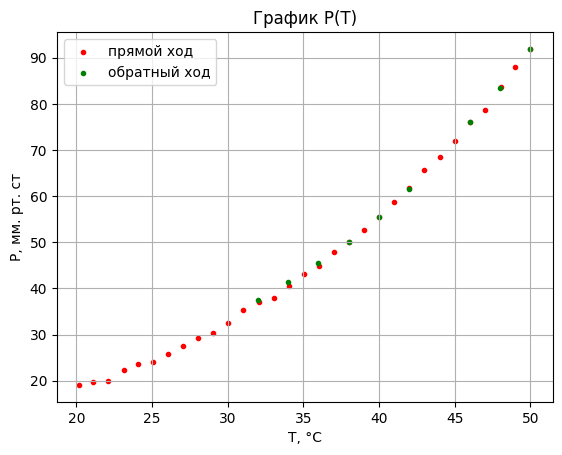

In [69]:
plt.scatter(data['Tp'], data['Pp'], marker='.', linewidths=1, color='red', label='прямой ход')
plt.scatter(data['To'], data['Po'], marker='.', linewidths=1, color='green', label='обратный ход')
plt.legend()
plt.xlabel("T, °C")
plt.ylabel("P, мм. рт. ст")
plt.title("График P(T)")
plt.grid(True)
plt.show()

Обратный ход почти идентичен прямому (точки близкие к 35 градусам снимались в спешке, поэтому они больше отклоняются от прямого хода)

In [70]:
lnp = np.log(data['Pp'])
obrT = np.pow(data['Tp']+273.15, -1)

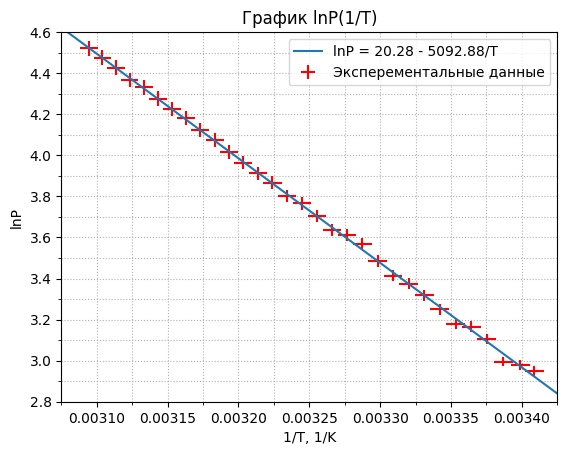

In [71]:
plt.errorbar(obrT, lnp, label='Эксперементальные данные',yerr=list(map(lambda x: x*0.008, lnp)), xerr=list(map(lambda x: x*0.002, obrT)), ecolor='red', color='none')

coeffs = np.polyfit(obrT, lnp, deg=1)
poly_func = np.poly1d(coeffs)
x = np.linspace(0.003075, 0.003425, 100)
y = poly_func(x)
plt.plot(x, y, label=f"lnP = {coeffs[1]:.2f} - {abs(coeffs[0]):.2f}/T")
ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.000025))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(0.003075, 0.003425)
ax.set_ylim(2.8, 4.6)
plt.title('График lnP(1/T)')
plt.xlabel("1/T, 1/K")
plt.ylabel("lnP")
plt.show()